Gaze-Based Interface for physically disabled users.

In [1]:
# ======================================
# 1. Mount Google Drive
# ======================================
# This allows us to access datasets and files stored in your Google Drive directly from Colab.

from google.colab import drive

# Mount the drive at the specified path
drive.mount('/content/drive')

print("\nGoogle Drive mounted successfully. Files can now be accessed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Google Drive mounted successfully. Files can now be accessed.


In [2]:
# ======================================
# 2. Verify Dataset Directory
# ======================================
import os

DATASET_PATH = "/content/drive/MyDrive/Gaze detection/"

# Check if path exists
if os.path.exists(DATASET_PATH):
    print("Dataset directory found.\n")
    print("Contents of the dataset directory:")
    for item in os.listdir(DATASET_PATH):
        print(f" - {item}")
else:
    print("Dataset directory not found. Please check the path.")

Dataset directory found.

Contents of the dataset directory:
 - X_mpiigaze_normalized.mat
 - Y_mpiigaze_gaze.mat


In [3]:
# ======================================
# 3. Check Individual Dataset Files
# ======================================
import os

X_FILE_PATH = "/content/drive/MyDrive/Gaze detection/X_mpiigaze_normalized.mat"
Y_FILE_PATH = "/content/drive/MyDrive/Gaze detection/Y_mpiigaze_gaze.mat"

# Check if each file exists and print a clear message
if os.path.exists(X_FILE_PATH):
    print(f"Found X dataset file: {X_FILE_PATH}")
else:
    print(f"X dataset file not found at: {X_FILE_PATH}")

if os.path.exists(Y_FILE_PATH):
    print(f"Found Y dataset file: {Y_FILE_PATH}")
else:
    print(f"Y dataset file not found at: {Y_FILE_PATH}")

Found X dataset file: /content/drive/MyDrive/Gaze detection/X_mpiigaze_normalized.mat
Found Y dataset file: /content/drive/MyDrive/Gaze detection/Y_mpiigaze_gaze.mat


In [4]:
# ======================================
# 4. Inspect Dataset Files
# ======================================
import os
import h5py
import numpy as np

# Paths to the dataset files
X_PATH = "/content/drive/MyDrive/Gaze detection/X_mpiigaze_normalized.mat"
Y_PATH = "/content/drive/MyDrive/Gaze detection/Y_mpiigaze_gaze.mat"

# 4a. Check size of Y dataset file
y_size_bytes = os.path.getsize(Y_PATH)
y_size_mb = y_size_bytes / (1024 * 1024)
print(f"Size of Y dataset file: {y_size_mb:.2f} MB")

# 4b. Open the X dataset file using h5py
X_file = h5py.File(X_PATH, 'r')

# List all datasets/keys inside the X file
x_keys = list(X_file.keys())
print("\nDatasets available inside X file:")
for key in x_keys:
    print(f" - {key}")

Size of Y dataset file: 9.17 MB

Datasets available inside X file:
 - X


In [5]:
# ======================================
# 5. Load and Inspect Dataset Shapes
# ======================================
import scipy.io

# ---- Load X dataset ----
X = X_file['X']  # Access the dataset inside the .mat file
print(f"Shape of X dataset: {X.shape}")

# ---- Load Y dataset ----
Y_path = "/content/drive/MyDrive/Gaze detection/Y_mpiigaze_gaze.mat"
Y_data = scipy.io.loadmat(Y_path)

print("\nKeys inside Y dataset file:")
for key in Y_data.keys():
    print(f" - {key}")  # just to confirm keys

# Extract the actual Y data
Y = Y_data['Y']  # Ensure this key matches
print(f"\nShape of Y dataset: {Y.shape}")

Shape of X dataset: (427316, 64, 64)

Keys inside Y dataset file:
 - __header__
 - __version__
 - __globals__
 - Y

Shape of Y dataset: (427316, 3)


In [6]:
# ======================================
# Inspect Dataset Shape
# ======================================

with h5py.File(X_PATH, 'r') as X_file:
    print("Available datasets:", list(X_file.keys()))
    print("Shape of X:", X_file['X'].shape)

Available datasets: ['X']
Shape of X: (427316, 64, 64)


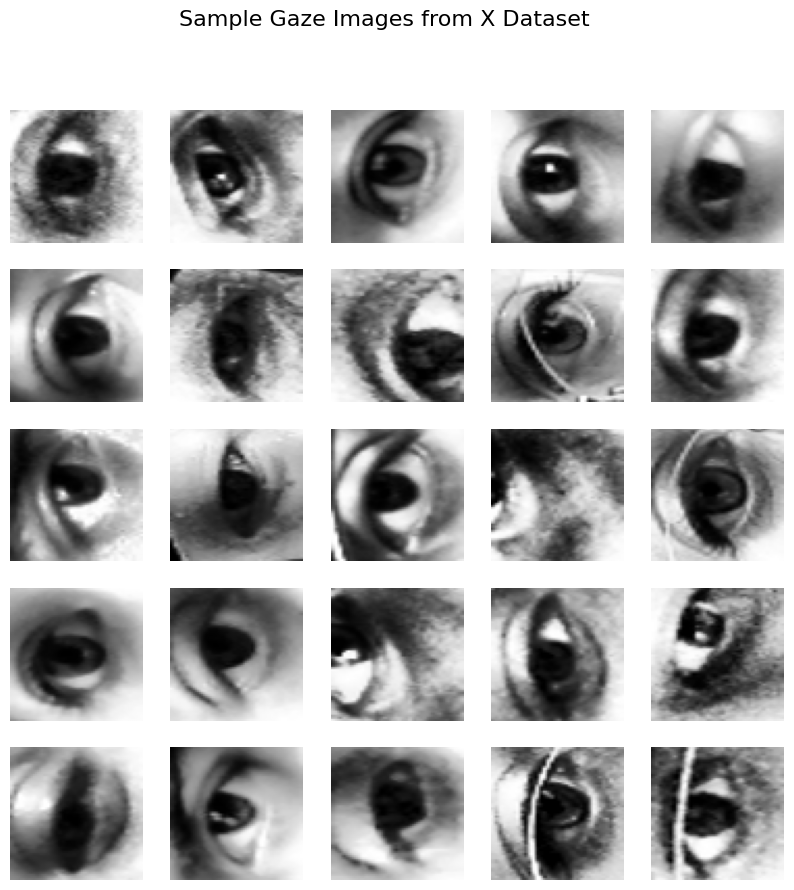

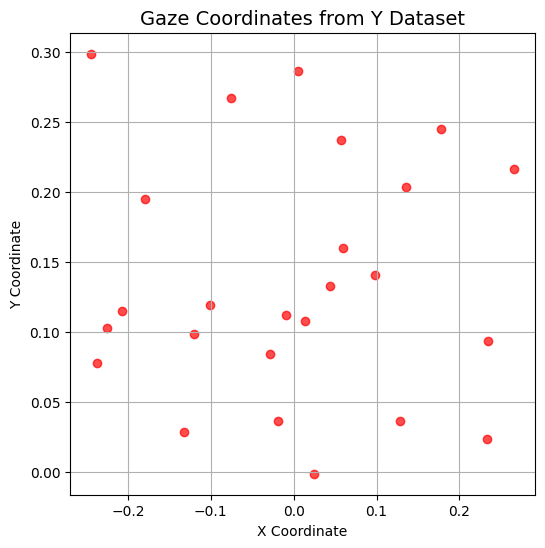

In [7]:
# ======================================
# 6. Visualize Sample Gaze Data
# ======================================
import matplotlib.pyplot as plt
import random

# ---- Visualize a random selection of 25 gaze images ----
num_samples_to_show = 25
indices = random.sample(range(X.shape[0]), num_samples_to_show)

plt.figure(figsize=(10,10))
for i, idx in enumerate(indices):
    plt.subplot(5,5,i+1)
    plt.imshow(X[idx], cmap='gray')  # assuming grayscale images
    plt.axis('off')
plt.suptitle("Sample Gaze Images from X Dataset", fontsize=16)
plt.show()

# ---- Visualize corresponding gaze points from Y ----
# Assuming Y has shape (num_samples, 2) with (x, y) coordinates
sample_Y = Y[indices]

plt.figure(figsize=(6,6))
plt.scatter(sample_Y[:,0], sample_Y[:,1], c='red', alpha=0.7)
plt.title("Gaze Coordinates from Y Dataset", fontsize=14)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

Sampled X shape: (20000, 64, 64)
Sampled Y shape: (20000, 3)


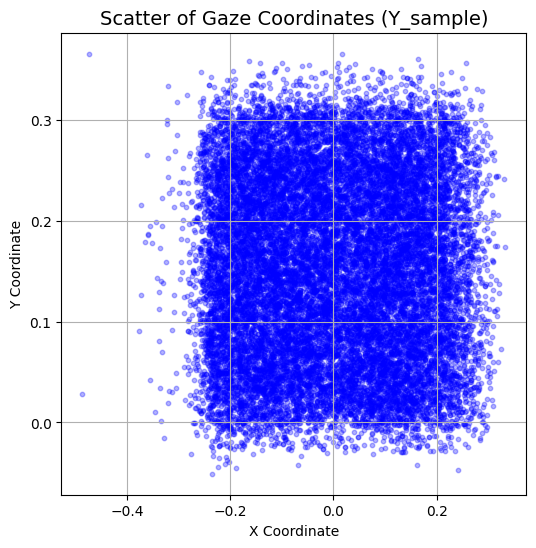

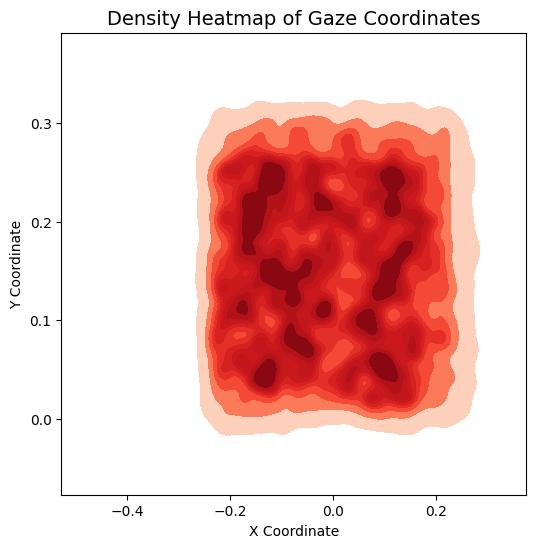

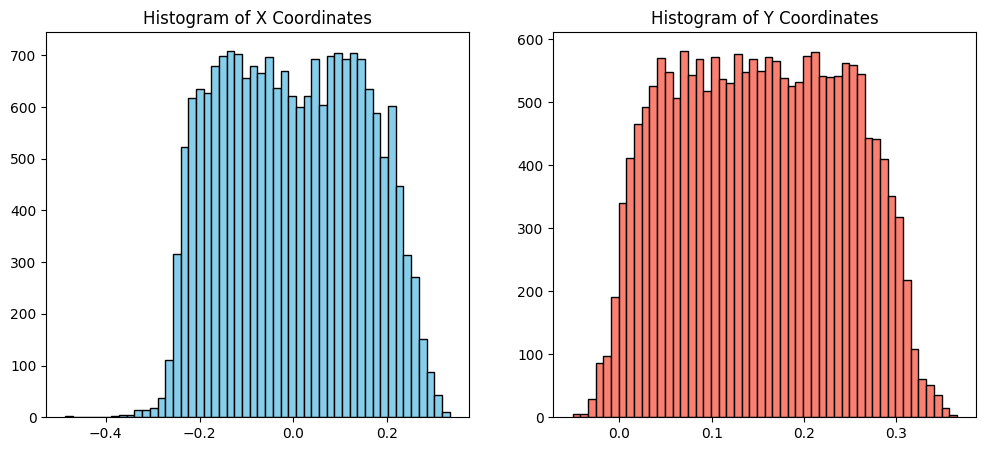

In [8]:
# ======================================
# 7. Visualize Gaze Coordinates Distribution
# ======================================

import numpy as np

num_samples = 20000
indices = np.random.choice(X.shape[0], num_samples, replace=False)
indices = np.sort(indices)

X_sample = X[indices].astype("float32")
Y_sample = Y[indices]

print(f"Sampled X shape: {X_sample.shape}")
print(f"Sampled Y shape: {Y_sample.shape}")
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of all sampled gaze points
plt.figure(figsize=(6,6))
plt.scatter(Y_sample[:,0], Y_sample[:,1], c='blue', alpha=0.3, s=10)
plt.title("Scatter of Gaze Coordinates (Y_sample)", fontsize=14)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

# Heatmap / density of gaze points
plt.figure(figsize=(6,6))
sns.kdeplot(
    x=Y_sample[:,0], y=Y_sample[:,1],
    fill=True, cmap='Reds', bw_adjust=0.5, thresh=0.05
)
plt.title("Density Heatmap of Gaze Coordinates", fontsize=14)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

# Optional: histogram for X and Y coordinates separately
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(Y_sample[:,0], bins=50, color='skyblue', edgecolor='black')
plt.title("Histogram of X Coordinates")
plt.subplot(1,2,2)
plt.hist(Y_sample[:,1], bins=50, color='salmon', edgecolor='black')
plt.title("Histogram of Y Coordinates")
plt.show()

In [9]:
# ======================================
# 8. Explore and Split Sampled Dataset
# ======================================
import numpy as np
from sklearn.model_selection import train_test_split

# Check the range of values in X_sample
print(f"🔹 X_sample range: min = {X_sample.min():.4f}, max = {X_sample.max():.4f}")

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X_sample, Y_sample,
    test_size=0.2,   # 20% for testing
    random_state=42  # ensures reproducibility
)

# ---- Print shapes of all splits ----
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

🔹 X_sample range: min = 0.0000, max = 1.0000
X_train shape: (16000, 64, 64)
Y_train shape: (16000, 3)
X_test shape: (4000, 64, 64)
Y_test shape: (4000, 3)


In [10]:
# ======================================
# 9. Inspect Y_sample & Install TensorFlow
# ======================================
import numpy as np
import sys
import tensorflow as tf

# Check the average magnitude of gaze vectors
mean_norm = np.mean(np.linalg.norm(Y_sample, axis=1))
print(f"🔹 Average magnitude of gaze vectors in Y_sample: {mean_norm:.4f}")

# Upgrade pip
!{sys.executable} -m pip install --upgrade pip

# Install TensorFlow (specific version)
!{sys.executable} -m pip install tensorflow
# Uninstall any conflicting versions
!pip uninstall -y tensorflow tensorflow-cpu tensorboard
!pip uninstall -y tensorflow tensorflow-cpu tensorboard
# Install desired version
!pip install tensorflow==2.20.0

# Import TensorFlow and check version
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

🔹 Average magnitude of gaze vectors in Y_sample: 1.0000
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: tensorboard 2.19.0
Uninstalling tensorboard-2.19.0:
  Successfully uninstalled tensorboard-2.19.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 43.2 MB/s  0:00:10
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 123.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 whic

TensorFlow version: 2.19.0


In [10]:
# ======================================
# 10. Normalize Gaze Vectors for Training
# ======================================
import numpy as np
import tensorflow as tf

# ---- Normalize Y_train and Y_test ----
# Each gaze vector is scaled to unit length
Y_train_norm = Y_train / np.linalg.norm(Y_train, axis=1, keepdims=True)
Y_test_norm  = Y_test  / np.linalg.norm(Y_test, axis=1, keepdims=True)

# ---- Verify normalization ----
print(f"🔹 Example normalized gaze vector (first sample): {Y_train_norm[0]}")
print(f"🔹 Norm of first sample vector: {np.linalg.norm(Y_train_norm[0]):.4f}")

🔹 Example normalized gaze vector (first sample): [-0.0387046   0.19749862 -0.97953879]
🔹 Norm of first sample vector: 1.0000


In [15]:
# ======================================
# 11. Build CNN Model for Gaze Prediction
# ======================================
from tensorflow.keras import layers, models
import tensorflow as tf

# Sequential CNN architecture
# Input: 64x64 grayscale eye image
# Output: 3D normalized gaze vector

model = models.Sequential([

    # First convolution block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    layers.MaxPooling2D(2,2),

    # Second convolution block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Third convolution block
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten feature maps
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Output 3D gaze vector
    layers.Dense(3),

    # Normalize output to unit vector
    layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# ======================================
# 12. Define Cosine Similarity Loss
# ======================================

# Loss = 1 - cosine similarity
# Since outputs are normalized, this directly penalizes angular difference
def cosine_loss(y_true, y_pred):
    y_true = tf.math.l2_normalize(y_true, axis=1)
    y_pred = tf.math.l2_normalize(y_pred, axis=1)
    return 1 - tf.reduce_sum(y_true * y_pred, axis=1)

In [17]:
# ======================================
# 13. Compile the Model
# ======================================

from tensorflow.keras import optimizers

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=cosine_loss
)

In [14]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow

In [18]:
!pip uninstall -y tensorflow tensorflow-cpu tensorboard

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: tensorboard 2.20.0
Uninstalling tensorboard-2.20.0:
  Successfully uninstalled tensorboard-2.20.0


In [19]:
!pip uninstall -y tensorflow tensorflow-cpu tensorboard

In [20]:
!pip install tensorflow==2.20.0

  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (620.7 MB)
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.


In [21]:
import tensorflow as tf
print(tf.__version__)  # should print 2.20.0

2.20.0


In [23]:
# ======================================
# 14. Train the Model
# ======================================

history = model.fit(
    X_train,
    Y_train_norm,
    validation_data=(X_test, Y_test_norm),
    epochs=25,
    batch_size=64,
    verbose=1
)

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 142s 557ms/step - loss: 0.0445 - val_loss: 0.0081
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 124s 497ms/step - loss: 0.0077 - val_loss: 0.0066
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 123s 423ms/step - loss: 0.0060 - val_loss: 0.0052
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 444ms/step - loss: 0.0049 - val_loss: 0.0048
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 105s 420ms/step - loss: 0.0044 - val_loss: 0.0044
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 114s 455ms/step - loss: 0.0040 - val_loss: 0.0043
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 431ms/step - loss: 0.0038 - val_loss: 0.0041
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 105s 420ms/step - loss: 0.0036 - val_loss: 0.0039
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 139s 407ms/step - loss: 0.0034 - val_loss: 0.0038
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 102s 408ms/step - loss: 0.0031 - val_loss: 0.0039
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 103s 413ms/step - loss: 0.0029 - val_loss: 0.0039
Epoch 12

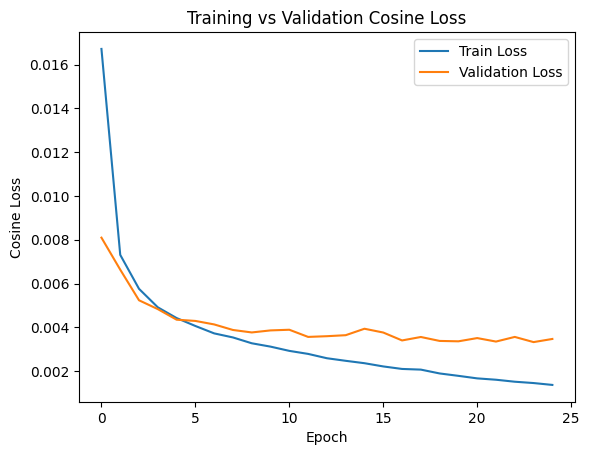

In [24]:
# ======================================
# 15. Visualize Training vs Validation Loss
# ======================================

import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Cosine Loss")
plt.title("Training vs Validation Cosine Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.show()

In [25]:
# ======================================
# 16. Evaluate Model using Angular Error
# ======================================

import numpy as np
import matplotlib.pyplot as plt

# ---- Generate Predictions ----
Y_pred = model.predict(X_test)

# ---- Compute Cosine Similarity ----
# Dot product between predicted and true normalized vectors
dot = np.sum(Y_pred * Y_test_norm, axis=1)

# Numerical stability (avoid arccos domain error)
dot = np.clip(dot, -1.0, 1.0)

# ---- Convert to Angular Error in Degrees ----
angles = np.degrees(np.arccos(dot))

# ---- Print Evaluation Metrics ----
print("Mean Angular Error (degrees):", np.mean(angles))
print("Median Angular Error (degrees):", np.median(angles))

125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step
Mean Angular Error (degrees): 3.724257930794517
Median Angular Error (degrees): 2.9608040145590886


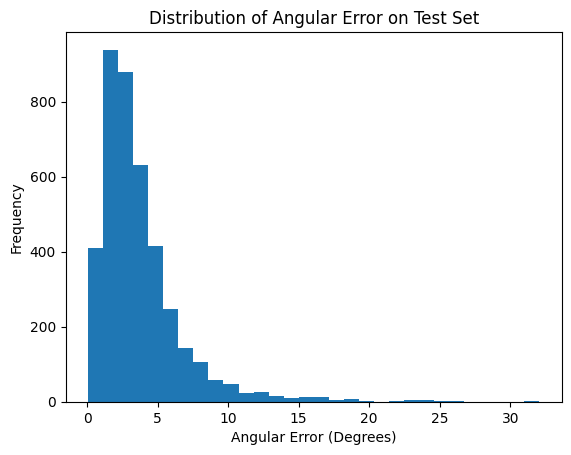

In [26]:
# ======================================
# 17. Visualize Angular Error Distribution
# ======================================

plt.figure()
plt.hist(angles, bins=30)
plt.xlabel("Angular Error (Degrees)")
plt.ylabel("Frequency")
plt.title("Distribution of Angular Error on Test Set")
plt.show()

In [27]:
# ======================================
# 18. Inspect Sample Predictions vs Ground Truth
# ======================================

# ---- Predict first 5 test samples ----
pred = model.predict(X_test[:5])

print("Predictions:")
print(pred)

print("\nGround Truth:")
print(Y_test[:5])


# ---- Compare Using Cosine Similarity ----
# Normalize ground truth to match model output format
true_norm = Y_test[:5] / np.linalg.norm(Y_test[:5], axis=1, keepdims=True)

dot = np.sum(pred * true_norm, axis=1)
dot = np.clip(dot, -1.0, 1.0)
angles = np.degrees(np.arccos(dot))

print("\nAngular Errors (degrees) for these 5 samples:")
print(angles)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Predictions:
[[ 0.18490171  0.2526487  -0.9497263 ]
 [-0.10821029  0.20711054 -0.9723146 ]
 [ 0.10504376  0.12267674 -0.98687184]
 [-0.06355044  0.08950132 -0.9939572 ]
 [ 0.26772442  0.23643517 -0.9340353 ]]

Ground Truth:
[[ 0.16981337  0.29256458 -0.94104696]
 [-0.15973208  0.23162432 -0.95960192]
 [ 0.13254263  0.11275781 -0.98474267]
 [-0.05000136  0.09948398 -0.99378207]
 [ 0.2703051   0.21208511 -0.93912462]]

Angular Errors (degrees) for these 5 samples:
[2.49518774 3.34976529 1.67962503 0.96414532 1.43310004]


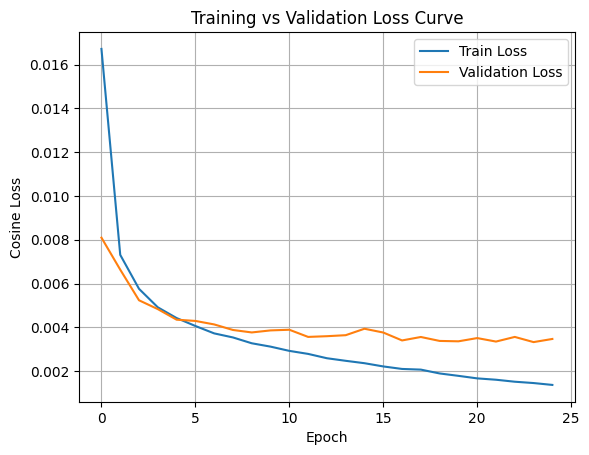

In [28]:
# ======================================
# 19. Plot Training and Validation Loss
# ======================================

import matplotlib.pyplot as plt

plt.figure()

# Plot training loss
plt.plot(history.history['loss'], label='Train Loss')

# Plot validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Cosine Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
# ======================================
# 20. Inspect Raw Loss Values
# ======================================

print("Training Loss per Epoch:")
print(history.history['loss'])

print("\nValidation Loss per Epoch:")
print(history.history['val_loss'])

Training Loss per Epoch:
[0.016712024807929993, 0.007312084082514048, 0.005760986357927322, 0.004917582962661982, 0.004427976440638304, 0.004065311048179865, 0.0037276875227689743, 0.003542177611961961, 0.0032763418275862932, 0.003123094793409109, 0.0029293186962604523, 0.002791259903460741, 0.00259346142411232, 0.0024761445820331573, 0.0023665998596698046, 0.0022191773168742657, 0.002104463055729866, 0.0020741743501275778, 0.0018988620722666383, 0.0017896104836836457, 0.0016739284619688988, 0.0016121161170303822, 0.0015214625746011734, 0.0014609418576583266, 0.0013753321254625916]

Validation Loss per Epoch:
[0.008097488433122635, 0.006636074278503656, 0.005238499492406845, 0.004835038911551237, 0.0043527125380933285, 0.004296127241104841, 0.004136586561799049, 0.003883191617205739, 0.0037707185838371515, 0.00386379798874259, 0.0038937553763389587, 0.0035666637122631073, 0.0035992723423987627, 0.003645231481641531, 0.003939710091799498, 0.0037667746655642986, 0.0034057910088449717, 0.

In [32]:
# ======================================
# 21. Additional Performance Metrics
# ======================================

import numpy as np

# Ensure predictions are normalized
Y_pred = model.predict(X_test)
Y_pred = Y_pred / np.linalg.norm(Y_pred, axis=1, keepdims=True)

# Normalize ground truth
Y_true = Y_test / np.linalg.norm(Y_test, axis=1, keepdims=True)

# ---- Cosine Similarity ----
cos_sim = np.sum(Y_pred * Y_true, axis=1)

mean_cos_sim = np.mean(cos_sim)

# ---- Angular Error ----
cos_sim = np.clip(cos_sim, -1.0, 1.0)
angles = np.degrees(np.arccos(cos_sim))

mean_angle = np.mean(angles)
median_angle = np.median(angles)

# ---- RMSE (vector space) ----
rmse = np.sqrt(np.mean((Y_pred - Y_true) ** 2))

# ---- Percentage within threshold ----
within_10 = np.mean(angles < 10) * 100
within_20 = np.mean(angles < 20) * 100
within_30 = np.mean(angles < 30) * 100

print("Mean Cosine Similarity:", mean_cos_sim)
print("Mean Angular Error (deg):", mean_angle)
print("Median Angular Error (deg):", median_angle)
print("RMSE:", rmse)
print("% within 10°:", within_10)
print("% within 20°:", within_20)
print("% within 30°:", within_30)

125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step
Mean Cosine Similarity: 0.9965269738425037
Mean Angular Error (deg): 3.724195654233573
Median Angular Error (deg): 2.9607666066998832
RMSE: 0.048118226907328844
% within 10°: 96.025
% within 20°: 99.625
% within 30°: 99.97500000000001


In [31]:
print(history.history['loss'])
print(history.history['val_loss'])

[0.016712024807929993, 0.007312084082514048, 0.005760986357927322, 0.004917582962661982, 0.004427976440638304, 0.004065311048179865, 0.0037276875227689743, 0.003542177611961961, 0.0032763418275862932, 0.003123094793409109, 0.0029293186962604523, 0.002791259903460741, 0.00259346142411232, 0.0024761445820331573, 0.0023665998596698046, 0.0022191773168742657, 0.002104463055729866, 0.0020741743501275778, 0.0018988620722666383, 0.0017896104836836457, 0.0016739284619688988, 0.0016121161170303822, 0.0015214625746011734, 0.0014609418576583266, 0.0013753321254625916]
[0.008097488433122635, 0.006636074278503656, 0.005238499492406845, 0.004835038911551237, 0.0043527125380933285, 0.004296127241104841, 0.004136586561799049, 0.003883191617205739, 0.0037707185838371515, 0.00386379798874259, 0.0038937553763389587, 0.0035666637122631073, 0.0035992723423987627, 0.003645231481641531, 0.003939710091799498, 0.0037667746655642986, 0.0034057910088449717, 0.0035632571671158075, 0.0033832795452326536, 0.0033656